# Train XGBoost model 

Use flattened data generated by `run/run_ml_prep.py`, where `run` is a string which indicates which round of processing was using (cuts/flattening technique), and hyperparameters found via the `optimise.ipynb` notebook.



In [1]:
import sys
sys.path.append("../../src/ml")

## Assemble dataset

run = "j" 

- 2026 MLPreprocess cuts with coinc start/end time
- All coincidences and all combinations of dt, each row is a coincidence
- Events with no coincidence have NaN CRV parameters 

In [2]:
run = "j" 
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
data = asm.assemble_dataset()

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/j/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [OK] Got ML data


In [3]:
asm.check_dT_window_results()

,Metric,CRY,CE Mix
0,Total,19574,297609
1,Unvetoed,10,264758
2,Fraction [%],99.95,11.04


[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/process/h1o_3x3_cuts_CRY.png


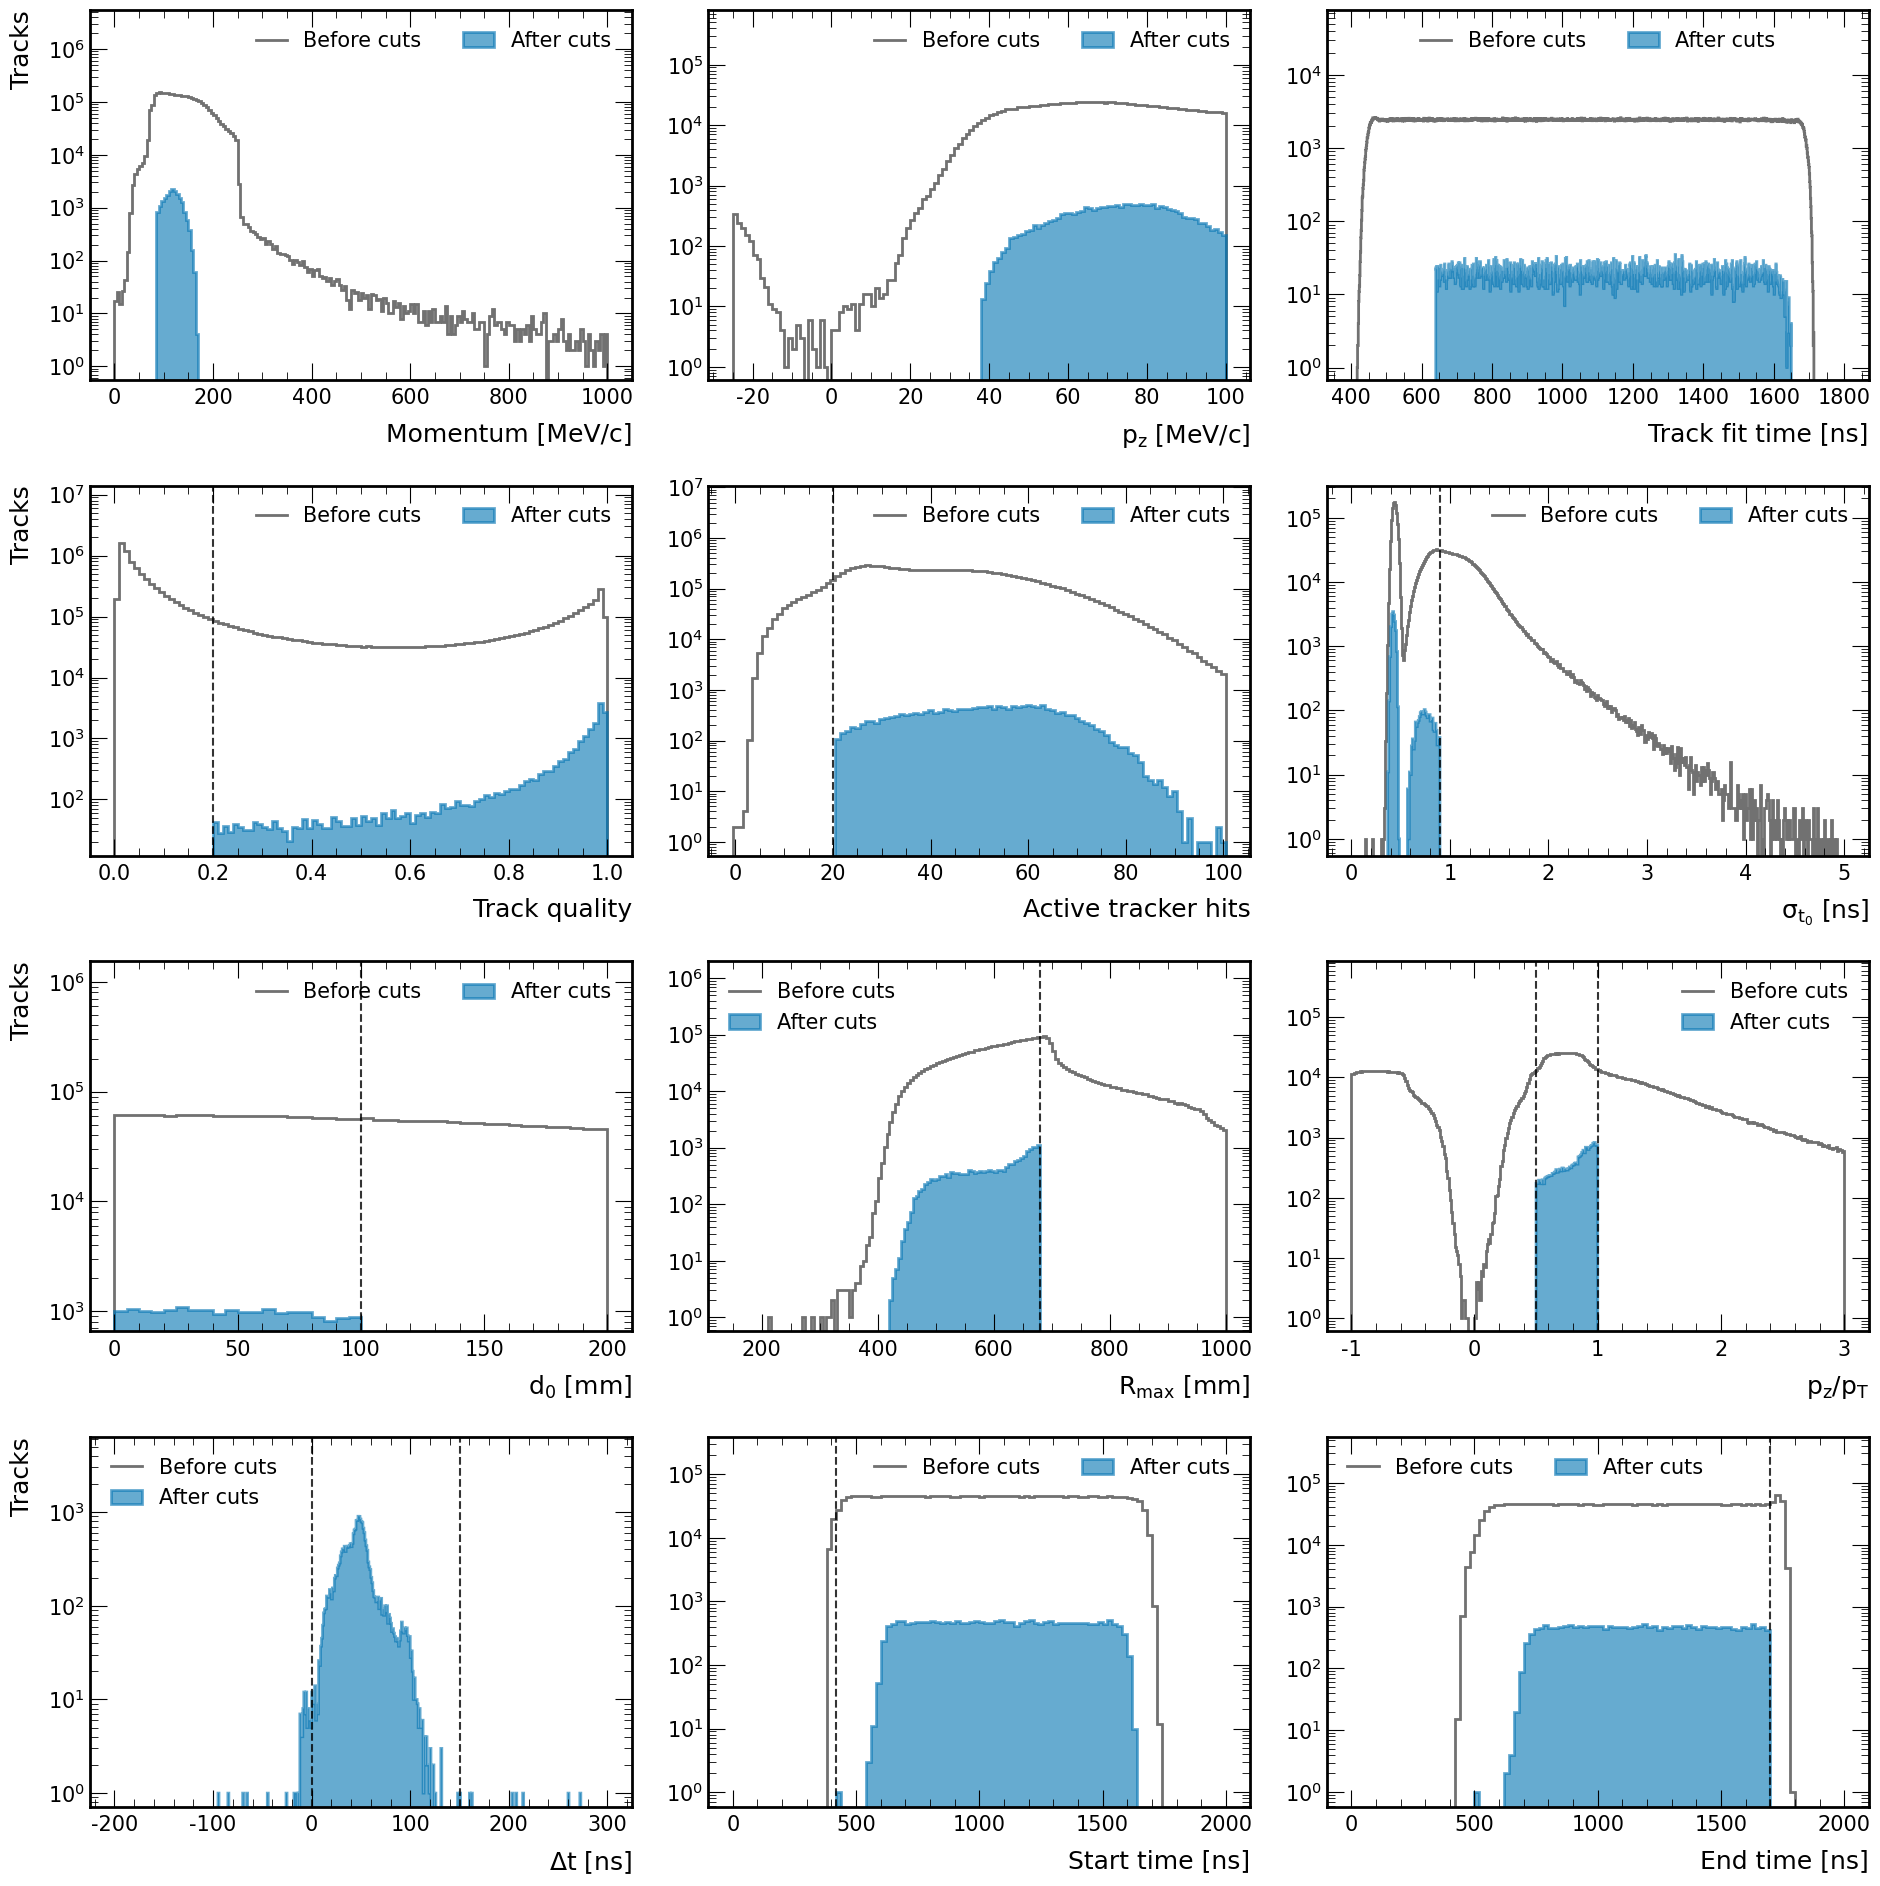

[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/process/h1o_3x3_cuts_CE_mix.png


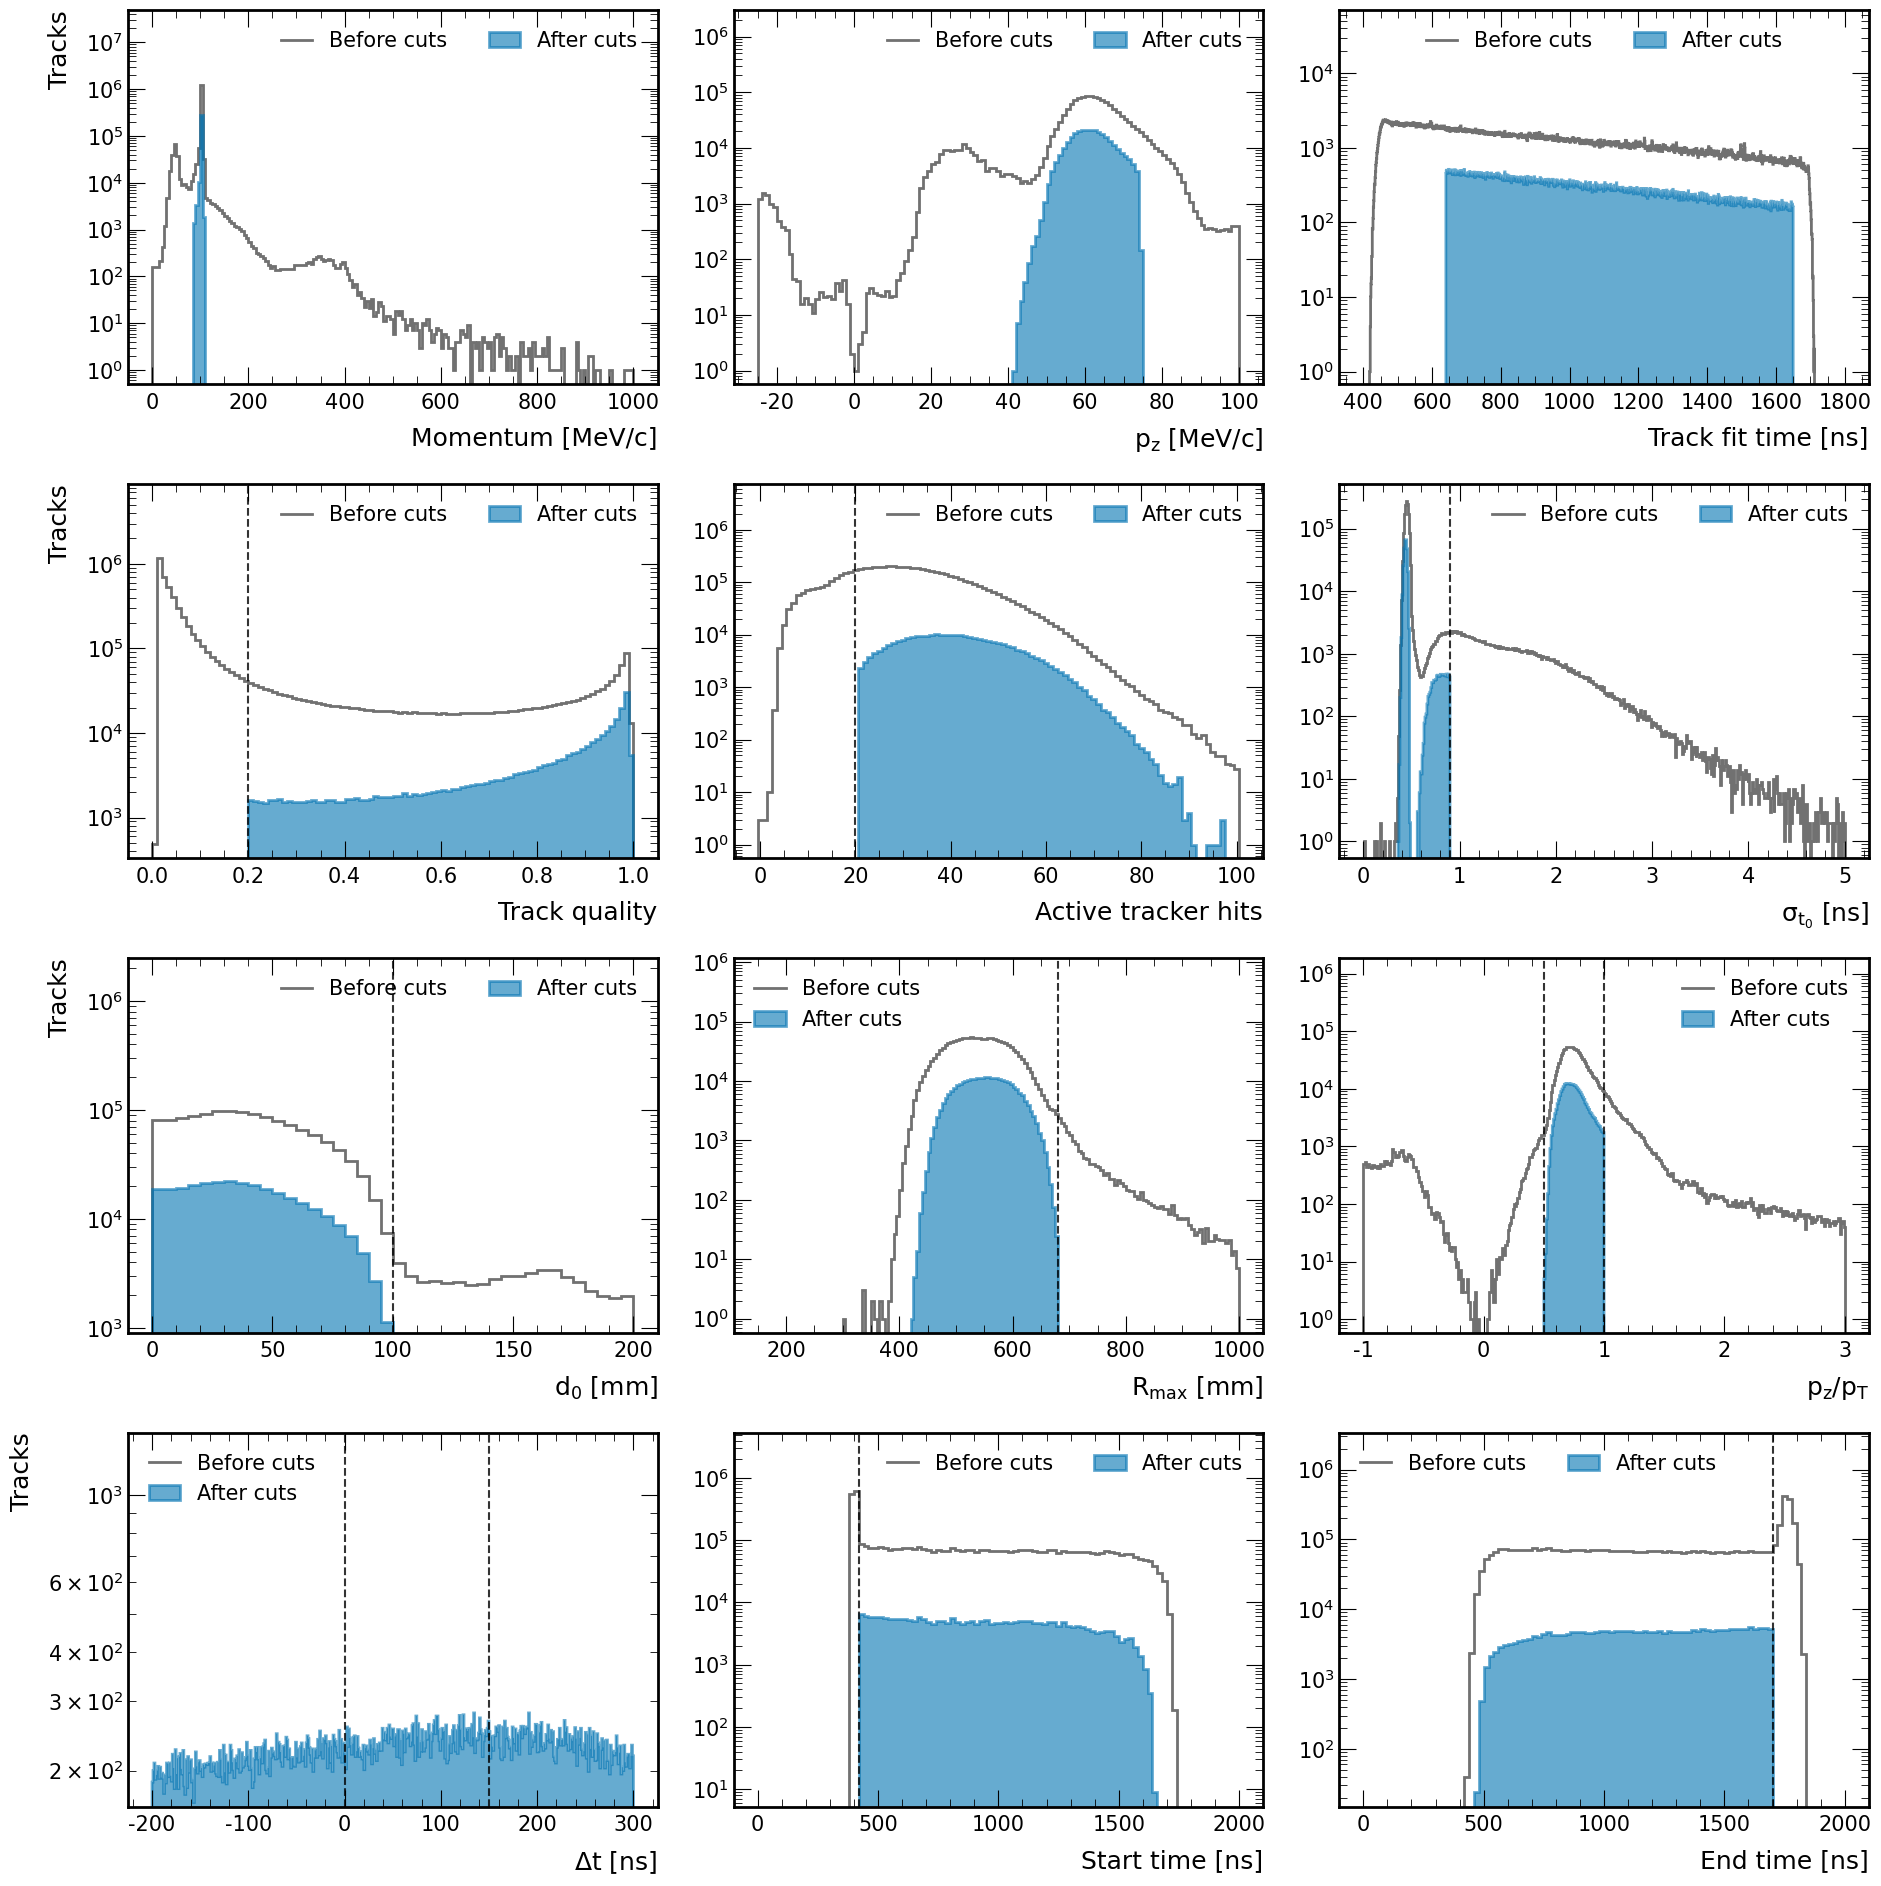

In [4]:
asm.draw_cuts()

[Assemble] [OK] Saved feature distributions to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/process/h1o_2x4_crv_features.png


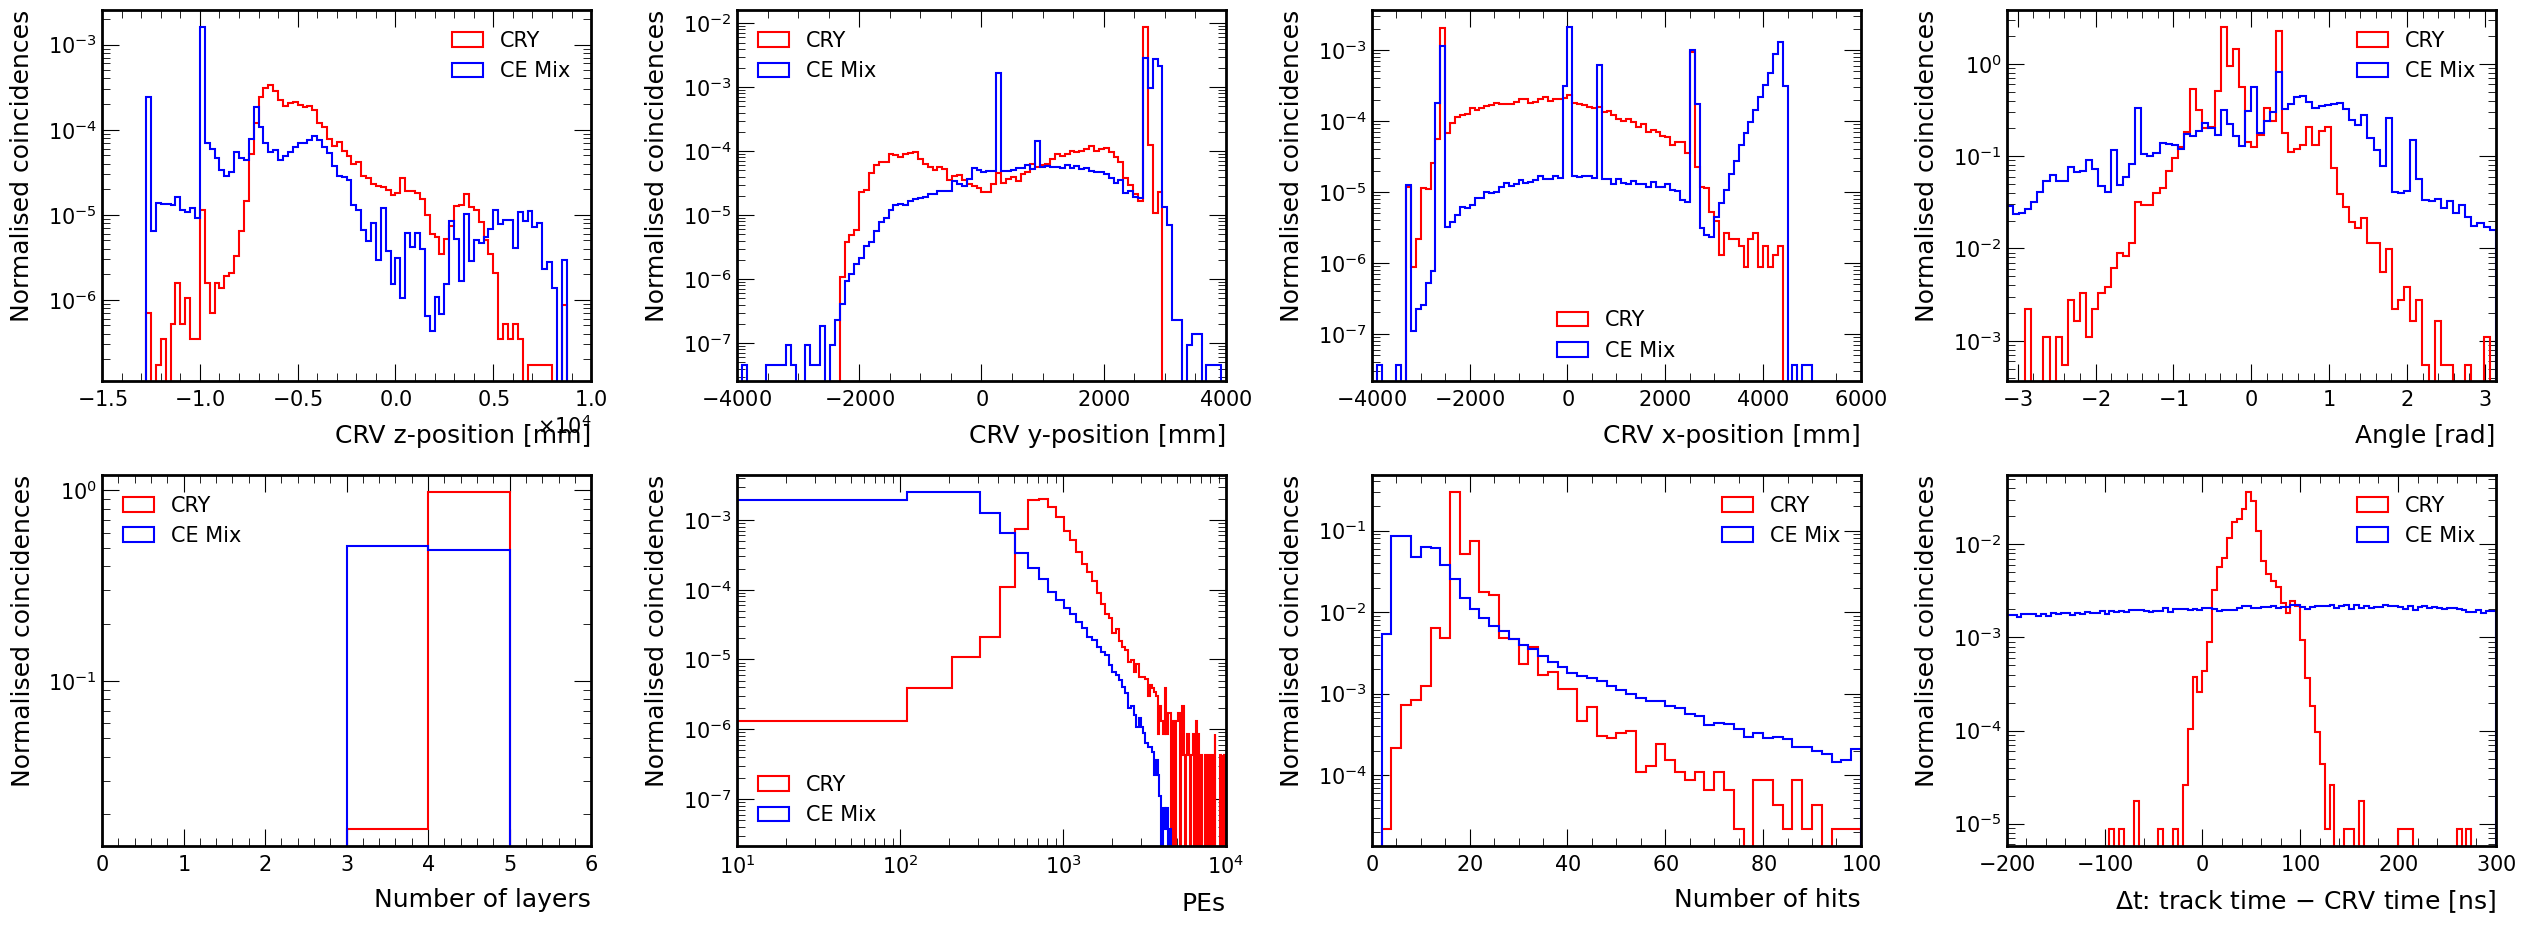

In [5]:
asm.draw_features()

## Train model

- Use hyperparameters found via grid search optimisation in optimise.ipynb 
- 80/20 test/train split 
- Threshold found with cross validation

Hyperparameters found c

In [6]:
best_hp = {
    "n_estimators": 500,
    "max_depth": 7,
    "learning_rate": 0.1
}

[Train] [OK] Initialised
[Train] [INFO] CV training: 5 folds, tag=xgb_optimised
  Hyperparams: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}
[Train] [INFO] CV results (5 folds):
  Threshold:       0.5582 +/- 0.2714
  Veto efficiency: 99.923 +/- 0.000%
  Deadtime:        0.023 +/- 0.014%
  AUC:             0.999804
[Train] [INFO] Training final model on full train set...
[Train] [INFO] Training model: XGBClassifier
  Tag: xgb_optimised
  Random state: 42
  Scale features: True

[Train] [INFO]   Hyperparams: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}

[Train] [OK] Training complete!
[Train] [OK] Use CV threshold: 0.5582 (not single-split threshold)
[Validate] [OK] Initialised analyser for model: xgb_optimised
[Validate] [OK] Saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/j/xgb_optimised/threshold_overlay_cv.png


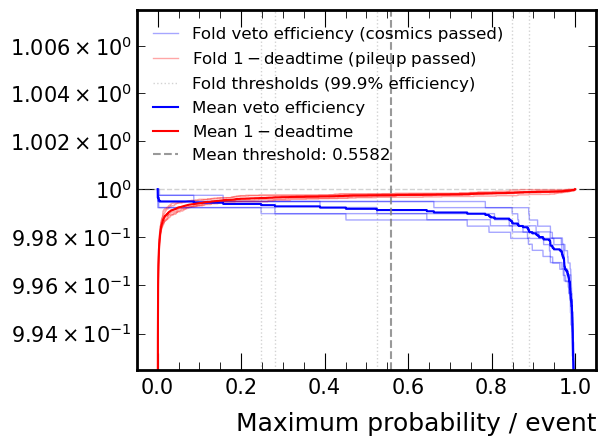

In [ ]:
from train import Train
trn = Train(data, run=run)
results = trn.train_cv(
    tag="xgb_optimised",
    n_folds=5, 
    save_output=True,
    **best_hp
)
threshold = results["cv_threshold"]